# PMM Dynamic — Optuna Parameter Optimization

This notebook optimizes the **PMM Dynamic** market-making strategy parameters using
**Optuna** (Bayesian TPE sampler). It reads historical candle data from **MongoDB**
(populated by `candle_ingest.py` on the Trading Pod) and finds the parameter set that
maximizes risk-adjusted returns (Sharpe ratio) while constraining max drawdown.

**What gets optimized:**
- MACD periods (fast, slow, signal) — controls mid-price shift
- NATR length — controls volatility measurement
- Spread multipliers + order levels — controls order placement distance (in NATR units)
- Triple barrier (stop loss, take profit, time limit, trailing stop) — controls exits
- Executor refresh rate — controls order replacement frequency

**Requirements:**
- MongoDB accessible at `MONGO_URI` with candle data
- `pmm_dynamic_optimizer.py` in the same directory or on `PYTHONPATH`
- `pip install optuna pymongo pandas numpy`
- Optional: `pip install optuna-dashboard plotly` for visualization

## 1. Setup & Configuration

In [1]:
import os
import sys
import logging
from datetime import datetime, timedelta, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# Load .env from project root (works both in Docker and locally)
try:
    from dotenv import load_dotenv
    _nb_dir = Path(".").resolve()
    for _parent in [_nb_dir] + list(_nb_dir.parents):
        _env_file = _parent / ".env"
        if _env_file.exists():
            load_dotenv(_env_file)
            break
except ImportError:
    pass

# Force deterministic Numba device-array backend for pmm_dynamic_optimizer_gpu
# (Overrides any .env setting; avoids CuPy stream/context pitfalls.)
os.environ["PMM_DYNAMIC_GPU_BACKEND"] = "numba"

# ── GPU detection ──
GPU_AVAILABLE = False
try:
    import cupy as cp
    import numba
    from numba import cuda as numba_cuda
    GPU_AVAILABLE = numba_cuda.is_available()
    if GPU_AVAILABLE:
        free, total = cp.cuda.Device(0).mem_info
        print(f"GPU detected: {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
        print(f"   VRAM: {free/1e9:.1f} GB free / {total/1e9:.1f} GB total")
        print(f"   CuPy: {cp.__version__}, Numba: {numba.__version__}")
except ImportError:
    print("GPU packages not installed (cupy/numba). Using CPU backend.")
except Exception as e:
    print(f"GPU detection failed: {e}. Using CPU backend.")

if GPU_AVAILABLE:
    from pmm_dynamic_optimizer_gpu import (
        create_objective_gpu, gpu_backtest_single,
        prepare_candles_gpu, get_gpu_info, get_gpu_backend,
        assert_cpu_gpu_parity,
    )
    print("Backend: GPU-accelerated backtester")
    print(f"pmm_dynamic GPU backend: {get_gpu_backend()} | info: {get_gpu_info()}")
else:
    print("Backend: CPU backtester")

# Common imports from CPU module (always available)
from pmm_dynamic_optimizer import (
    load_candles, PMMDynamicConfig, PMMDynamicBacktester,
    create_objective, trial_to_controller_yaml, trial_to_config,
)

# V3: Validation and post-optimization gates
from pmm_dynamic_core import (
    walk_forward_evaluate, stress_test_config, validate_candles,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(name)s %(levelname)s %(message)s")
log = logging.getLogger("optimize")

print(f"Optuna version: {optuna.__version__}")
print(f"NumPy version:  {np.__version__}")
print(f"Pandas version: {pd.__version__}")

GPU detected: NVIDIA GeForce RTX 4090
   VRAM: 24.1 GB free / 25.8 GB total
   CuPy: 14.0.1, Numba: 0.61.2
Backend: GPU-accelerated backtester
pmm_dynamic GPU backend: numba | info: {'name': 'NVIDIA GeForce RTX 4090', 'compute_capability': ComputeCapability(major=8, minor=9), 'backend': 'numba'}
Optuna version: 4.7.0
NumPy version:  2.2.6
Pandas version: 3.0.1


In [2]:
# =============================================================================
# CONFIGURATION — Edit this cell only. All other cells read constants from here.
#
# NonKYC.io recommended live-deployment settings are pre-filled below.
# Settings marked PAPER-ONLY should be changed before live trading.
# =============================================================================

# MongoDB connection — reads from environment (set by Docker compose or .env)
TRUENAS_IP = os.environ.get("TRUENAS_LAN_IP", "192.168.1.54")
TRUENAS_DB_PASS = os.environ.get("MONGO_ROOT_PASSWORD", "mypass")
MONGO_URI = os.environ.get(
    "MONGO_URI",
    f"mongodb://admin:{TRUENAS_DB_PASS}@{TRUENAS_IP}:27017/quants_lab?authSource=admin"
)
MONGO_DATABASE = os.environ.get("MONGO_DATABASE", "quants_lab")

CONNECTOR          = "nonkyc"
TRADING_PAIR       = "BTC-USDT"
INTERVAL           = "5m"
TOTAL_AMOUNT_QUOTE = 1000.0
LEVERAGE           = 1
N_LEVELS           = 2

OPTIMIZE_METRIC         = "sharpe_ratio"
MAX_DRAWDOWN_CONSTRAINT = 0.15
OPTIMIZE_N_LEVELS       = False
OPTIMIZE_AMOUNTS        = True
SPREAD_MIN              = 0.5
SPREAD_MAX              = 8.0
SPREAD_STEP             = 0.1

# ── Candle semantics (V3) ─────────────────────────────────────────────────────
# TIMESTAMP_MODE: "open" if your data source timestamps are candle OPEN times
#   (NonKYC.io / most exchanges use OPEN times). Using "close" incorrectly
#   creates look-ahead bias. Use "unknown" to apply a 1-candle safety shift.
TIMESTAMP_MODE = "open"
# VOLUME_UNITS: "base" if volume column is in base currency, "quote" if already
#   in quote currency. Most exchanges report volume in base.
VOLUME_UNITS = "base"

# ── Fees (NonKYC.io) ──────────────────────────────────────────────────────────
MAKER_FEE = 0.001   # 0.1% — entry orders rest on book as maker
TAKER_FEE = 0.002   # 0.2% — barrier exits execute as taker

# ── Execution realism ─────────────────────────────────────────────────────────
SLIPPAGE_MAX_PCT = 0.001   # 0.1% avg adverse slippage per fill
FILL_RATE_PCT    = 0.05    # order must be ≤ 5% of candle volume to fill
COOLDOWN_SECONDS = 15      # wait 15s after a close before re-quoting (live default)

# ── Capital controls ──────────────────────────────────────────────────────────
DEPLOY_FRACTION    = 0.4   # 40% of capital deployed per refresh (each side)
MAX_OPEN_POSITIONS = 4     # 2 levels × 2 sides
MAX_ORDER_QUOTE    = 0.0   # 0 = unlimited; set to capital/10 for large accounts
COMPOUNDING        = False # False = fixed sizes (reduces drawdown volatility)

# ── Quality gates ─────────────────────────────────────────────────────────────
MIN_TRADES               = 50    # reject configs with < 50 completed round trips
MAX_TRADES_PER_DAY       = 20.0  # turnover cap (excessive trading bleeds fees)
TURNOVER_PENALTY_WEIGHT  = 0.1
N_EVAL_SEEDS             = 3     # median of 3 capital jitters for robustness
AUTO_SPREAD_FLOOR        = True  # auto-floor spread at breakeven + 20% buffer

# -- Reviewer V4 options --
ENFORCE_SPREAD_FLOOR = False    # False = match Hummingbot exactly (reviewer §2.4)
ENFORCE_NC_GUARD = False        # False = match Hummingbot exactly (reviewer §2.4)
COOLDOWN_SL_ONLY = True         # True = match Hummingbot: cooldown after stop_loss only

# -- Determinism --
SEED = 42
import random; random.seed(SEED); np.random.seed(SEED)
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

N_TRIALS = 500

# Backtest window
BACKTEST_DAYS = 100
END_DATE = None

# GPU optimization settings
FORCE_CPU = False
GPU_DTYPE = "float64"  # V3: always use float64 for GPU parity with CPU

# turn on comparison when in dev
DEV_VALUE = False

# Optuna study persistence
STUDY_NAME = f"pmm_dynamic_{CONNECTOR}_{TRADING_PAIR.replace('/', '_')}_{INTERVAL}"
STUDY_STORAGE = os.environ.get(
    "OPTUNA_STORAGE",
    f"sqlite:///optuna_{STUDY_NAME}.db"
)

print(f"Study:     {STUDY_NAME}")
print(f"Storage:   {STUDY_STORAGE.split('@')[0]}...")
print(f"Connector: {CONNECTOR}")
print(f"Pair:      {TRADING_PAIR}")
print(f"Interval:  {INTERVAL}")
print(f"Timestamp: {TIMESTAMP_MODE}")
print(f"Vol units: {VOLUME_UNITS}")
if FORCE_CPU and GPU_AVAILABLE:
    GPU_AVAILABLE = False
    print("Backend:   CPU (forced via FORCE_CPU=True)")
else:
    print(f"Backend:   {'GPU (per-trial)' if GPU_AVAILABLE else 'CPU'}")
print(f"Trials:    {N_TRIALS}")

Study:     pmm_dynamic_nonkyc_BTC-USDT_5m
Storage:   postgresql+psycopg2://optuna:optuna...
Connector: nonkyc
Pair:      BTC-USDT
Interval:  5m
Timestamp: open
Vol units: base
Backend:   GPU (per-trial)
Trials:    500


## 2. Load Candle Data from MongoDB

In [3]:
# Calculate date range
end = END_DATE or pd.Timestamp.now(tz="UTC")
start = end - pd.Timedelta(days=BACKTEST_DAYS)

print(f"Loading candles: {CONNECTOR} {TRADING_PAIR} {INTERVAL}")
print(f"  Range: {start.date()} → {end.date()} ({BACKTEST_DAYS} days)")

candles = load_candles(
    connector=CONNECTOR,
    pair=TRADING_PAIR,
    interval=INTERVAL,
    start=start,
    end=end,
    db_name=MONGO_DATABASE,
    mongo_uri=MONGO_URI,
)

print(f"  Loaded {len(candles):,} candles")
if len(candles) > 0:
    print(f"  First: {candles.iloc[0]['timestamp']}")
    print(f"  Last:  {candles.iloc[-1]['timestamp']}")
    print(f"  Price range: {candles['low'].min():.2f} — {candles['high'].max():.2f}")
else:
    raise RuntimeError(
        f"No candles found! Check that candle_ingest has run and MongoDB is accessible at {MONGO_URI}"
    )

Loading candles: nonkyc BTC-USDT 5m
  Range: 2025-11-26 → 2026-03-06 (100 days)
  Loaded 28,662 candles
  First: 2025-11-26 02:40:00+00:00
  Last:  2026-03-06 02:20:00+00:00
  Price range: 60215.53 — 98000.00


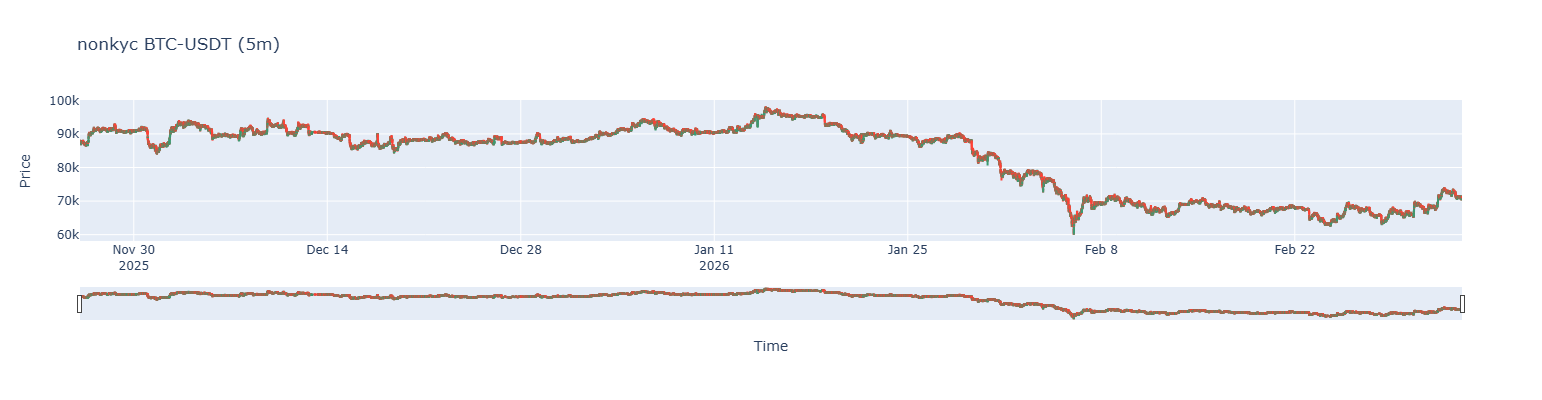

In [4]:
# Quick visual sanity check
try:
    import plotly.graph_objects as go

    fig = go.Figure(data=[go.Candlestick(
        x=candles["timestamp"],
        open=candles["open"],
        high=candles["high"],
        low=candles["low"],
        close=candles["close"],
    )])
    fig.update_layout(
        title=f"{CONNECTOR} {TRADING_PAIR} ({INTERVAL})",
        xaxis_title="Time",
        yaxis_title="Price",
        height=400,
    )
    fig.show()
except ImportError:
    print("(Install plotly for interactive charts: pip install plotly)")
    print(candles[["timestamp", "close"]].describe())

In [5]:
# Upload candle data to GPU VRAM (if available)
if GPU_AVAILABLE:
    candles_gpu = prepare_candles_gpu(candles, interval=INTERVAL, dtype=GPU_DTYPE)
    get_gpu_info()
    print(f"Candle data uploaded to GPU ({len(candles):,} candles, dtype={GPU_DTYPE})")
else:
    candles_gpu = None
    print("GPU not available — will use CPU backend")

Candle data uploaded to GPU (28,662 candles, dtype=float64)


In [6]:
# ── Pre-optimization parity gate (V4) ──
# Verify CPU/GPU produce matching results for BOTH timestamp modes
# before committing to 500 GPU trials.
if GPU_AVAILABLE:
#if 1==0:
    from pmm_dynamic_optimizer_parity_test import generate_synthetic_candles, TEST_PARAMS
    _test_candles = generate_synthetic_candles(n=2000, seed=42)
    _test_gpu = prepare_candles_gpu(_test_candles, interval="5m", dtype="float64")
    _parity_ok = True

    for i, tp in enumerate(TEST_PARAMS[:3]):
        for _ts_shift in [0, 1]:
            _mode_label = "close" if _ts_shift == 0 else "open/unknown"
            try:
                parity = assert_cpu_gpu_parity(
                    _test_candles, tp,
                    timestamp_shift=_ts_shift,
                    enforce_spread_floor=False,
                    enforce_nc_guard=False,
                    cooldown_sl_only=True,
                )
                status = "PASS" if parity["pass"] else "FAIL"
                if not parity["pass"]:
                    _parity_ok = False
                print(f"Parity test {i+1} (shift={_ts_shift}, {_mode_label}): {status}")
            except Exception as e:
                print(f"Parity test {i+1} (shift={_ts_shift}, {_mode_label}): FAIL -- {e}")
                _parity_ok = False

    if not _parity_ok:
        raise RuntimeError("GPU/CPU parity failed. Fix before running optimization.")
    print("All parity tests passed (both timestamp modes). GPU is safe to use.")
    del _test_candles, _test_gpu
else:
    print("GPU not available -- skipping parity gate")


2026-03-05 19:38:49,162 pmm_dynamic_optimizer WARNING validate_candles: TIMESTAMP SEMANTICS: Cannot auto-detect whether timestamps are OPEN-TIME or CLOSE-TIME. Set timestamp_mode='close' ONLY if you have confirmed your data source timestamps represent candle CLOSE times. Most exchanges (including NonKYC.io) use OPEN times. When in doubt, use timestamp_mode='open' (conservative, no look-ahead).
/opt/conda/envs/quants-lab/lib/python3.12/site-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Parity test 1 (shift=0, close): FAIL -- CPU/GPU parity failed: diffs={'n_trades_mismatch': 241, 'n_trades': 1.0, 'pnl_pct_abs': np.float64(0.260115586085562), 'max_dd_abs': np.float64(0.007845727722894012), 'sharpe_abs': np.float64(41.434122550485256), 'final_balance_rel': 0.14911554639631566, 'gross_win': np.float64(1.0), 'gross_loss': np.float64(1.0)}, cpu={'sharpe': np.float64(31.434122550485252), 'pnl_pct': np.float64(0.7443894508104013), 'max_dd': np.float64(0.057174355273991666), 'n_trades': 241, 'gross_win': np.float64(424.5107436262693), 'gross_loss': np.float64(164.3951575407062), 'final_balance': 1744.3894508104013}, gpu={'sharpe': -10.0, 'pnl_pct': 0.4842738647248393, 'max_dd': 0.06502008299688568, 'n_trades': 0, 'gross_win': 0.0, 'gross_loss': 0.0, 'final_balance': 1484.2738647248393}
Parity test 1 (shift=1, open/unknown): FAIL -- CPU/GPU parity failed: diffs={'n_trades_mismatch': 238, 'n_trades': 1.0, 'pnl_pct_abs': np.float64(0.2809512878762475), 'max_dd_abs': np.float64(

RuntimeError: GPU/CPU parity failed. Fix before running optimization.

baseline_cfg = PMMDynamicConfig(
    connector=CONNECTOR,
    trading_pair=TRADING_PAIR,
    interval=INTERVAL,
    total_amount_quote=TOTAL_AMOUNT_QUOTE,
    leverage=LEVERAGE,
    maker_fee=MAKER_FEE,
    taker_fee=TAKER_FEE,
    compounding=COMPOUNDING,
    max_order_quote=MAX_ORDER_QUOTE,
    slippage_max_pct=SLIPPAGE_MAX_PCT,
    fill_rate_pct=FILL_RATE_PCT,
    max_open_positions=MAX_OPEN_POSITIONS,
    deploy_fraction=DEPLOY_FRACTION,
    timestamp_mode=TIMESTAMP_MODE,
    volume_units=VOLUME_UNITS,
    # Defaults: MACD(21,42,9), NATR(14), spreads [1.0x, 2.0x NATR], SL 3%, TP 2%
)

bt = PMMDynamicBacktester(baseline_cfg)
baseline = bt.run(candles)

print("=" * 50)
print("BASELINE RESULTS (default parameters)")
print("=" * 50)
print(f"  Net PnL:        {baseline.net_pnl:+.2f} USDT ({baseline.net_pnl_pct:+.1%})")
print(f"  Sharpe Ratio:   {baseline.sharpe_ratio:.3f}")
print(f"  Max Drawdown:   {baseline.max_drawdown:.1%}")
print(f"  Profit Factor:  {baseline.profit_factor:.2f}")
print(f"  Win Rate:       {baseline.win_rate:.1%}")
print(f"  Total Trades:   {baseline.total_trades}")
print(f"  Avg Trade PnL:  {baseline.avg_trade_pnl:+.4f} USDT")
print(f"  Exits -- TP: {baseline.n_take_profit}, SL: {baseline.n_stop_loss}, "
      f"Trail: {baseline.n_trailing_stop}, Time: {baseline.n_time_limit}, "
      f"EOD: {baseline.n_end_of_data}")

In [ ]:
baseline_cfg = PMMDynamicConfig(
    connector=CONNECTOR,
    trading_pair=TRADING_PAIR,
    interval=INTERVAL,
    total_amount_quote=TOTAL_AMOUNT_QUOTE,
    leverage=LEVERAGE,
    maker_fee=MAKER_FEE,
    taker_fee=TAKER_FEE,
    compounding=COMPOUNDING,
    max_order_quote=MAX_ORDER_QUOTE,
    slippage_max_pct=SLIPPAGE_MAX_PCT,
    fill_rate_pct=FILL_RATE_PCT,
    max_open_positions=MAX_OPEN_POSITIONS,
    deploy_fraction=DEPLOY_FRACTION,
    # Defaults: MACD(21,42,9), NATR(14), spreads [1.0x, 2.0x NATR], SL 3%, TP 2%
)

bt = PMMDynamicBacktester(baseline_cfg)
baseline = bt.run(candles)

print("=" * 50)
print("BASELINE RESULTS (default parameters)")
print("=" * 50)
print(f"  Net PnL:        {baseline.net_pnl:+.2f} USDT ({baseline.net_pnl_pct:+.1%})")
print(f"  Sharpe Ratio:   {baseline.sharpe_ratio:.3f}")
print(f"  Max Drawdown:   {baseline.max_drawdown:.1%}")
print(f"  Profit Factor:  {baseline.profit_factor:.2f}")
print(f"  Win Rate:       {baseline.win_rate:.1%}")
print(f"  Total Trades:   {baseline.total_trades}")
print(f"  Avg Trade PnL:  {baseline.avg_trade_pnl:+.4f} USDT")
print(f"  Exits -- TP: {baseline.n_take_profit}, SL: {baseline.n_stop_loss}, "
      f"Trail: {baseline.n_trailing_stop}, Time: {baseline.n_time_limit}, "
      f"EOD: {baseline.n_end_of_data}")

## 4. Run Optuna Optimization

This is the main optimization loop. Optuna's TPE sampler intelligently explores
the parameter space, focusing on regions that produce better results.

The study is persisted to SQLite, so you can:
- Stop and resume without losing progress
- Run more trials later by re-running this cell
- Visualize with `optuna-dashboard`

In [ ]:
%%time

# Run the optimization — auto-selects GPU or CPU backend
if remaining > 0:
    if GPU_AVAILABLE:
        # Per-trial GPU optimization
        _ts_shift = 1 if TIMESTAMP_MODE in ("open", "unknown") else 0
        _vol_quote = VOLUME_UNITS == "quote"
        objective = create_objective_gpu(
            candles_gpu=candles_gpu,
            connector=CONNECTOR,
            trading_pair=TRADING_PAIR,
            interval=INTERVAL,
            total_amount_quote=TOTAL_AMOUNT_QUOTE,
            leverage=LEVERAGE,
            n_levels=N_LEVELS,
            optimize_metric=OPTIMIZE_METRIC,
            max_drawdown_constraint=MAX_DRAWDOWN_CONSTRAINT,
            maker_fee=MAKER_FEE,
            taker_fee=TAKER_FEE,
            spread_min=SPREAD_MIN,
            spread_max=SPREAD_MAX,
            spread_step=SPREAD_STEP,
            optimize_n_levels=OPTIMIZE_N_LEVELS,
            optimize_amounts=OPTIMIZE_AMOUNTS,
            deploy_fraction=DEPLOY_FRACTION,
            compounding=COMPOUNDING,
            max_order_quote=MAX_ORDER_QUOTE,
            slippage_max_pct=SLIPPAGE_MAX_PCT,
            fill_rate_pct=FILL_RATE_PCT,
            max_open_positions=MAX_OPEN_POSITIONS,
            cooldown_seconds=COOLDOWN_SECONDS,
            min_spread_floor=0.0,
            auto_spread_floor=AUTO_SPREAD_FLOOR,
            min_trades=MIN_TRADES,
            max_trades_per_day=MAX_TRADES_PER_DAY,
            turnover_penalty_weight=TURNOVER_PENALTY_WEIGHT,
            candles_df=candles,                         # V3: always pass candles_df
            timestamp_shift=_ts_shift,                  # V3: timestamp semantics
            volume_is_quote=_vol_quote,                 # V3: volume units
            enforce_spread_floor=ENFORCE_SPREAD_FLOOR,  # V4: spread floor mode
            enforce_nc_guard=ENFORCE_NC_GUARD,          # V4: non-crossing guard
            cooldown_sl_only=COOLDOWN_SL_ONLY,          # V4: cooldown mode
            use_enhanced=True,                          # V4: reviewer's formula
        )
        study.optimize(objective, n_trials=remaining, show_progress_bar=True)
    else:
        # CPU fallback
        objective = create_objective(
            candles,
            connector=CONNECTOR,
            trading_pair=TRADING_PAIR,
            interval=INTERVAL,
            total_amount_quote=TOTAL_AMOUNT_QUOTE,
            leverage=LEVERAGE,
            n_levels=N_LEVELS,
            optimize_metric=OPTIMIZE_METRIC,
            max_drawdown_constraint=MAX_DRAWDOWN_CONSTRAINT,
            maker_fee=MAKER_FEE,
            taker_fee=TAKER_FEE,
            spread_min=SPREAD_MIN,
            spread_max=SPREAD_MAX,
            spread_step=SPREAD_STEP,
            optimize_n_levels=OPTIMIZE_N_LEVELS,
            optimize_amounts=OPTIMIZE_AMOUNTS,
            deploy_fraction=DEPLOY_FRACTION,
            compounding=COMPOUNDING,
            max_order_quote=MAX_ORDER_QUOTE,
            slippage_max_pct=SLIPPAGE_MAX_PCT,
            fill_rate_pct=FILL_RATE_PCT,
            max_open_positions=MAX_OPEN_POSITIONS,
            min_trades=MIN_TRADES,
            max_trades_per_day=MAX_TRADES_PER_DAY,
            turnover_penalty_weight=TURNOVER_PENALTY_WEIGHT,
            n_eval_seeds=N_EVAL_SEEDS,
            auto_spread_floor=AUTO_SPREAD_FLOOR,
            timestamp_mode=TIMESTAMP_MODE,
            volume_units=VOLUME_UNITS,
            enforce_spread_floor=ENFORCE_SPREAD_FLOOR,
            enforce_nc_guard=ENFORCE_NC_GUARD,
            cooldown_on_stop_loss_only=COOLDOWN_SL_ONLY,
            use_enhanced=True,
        )
        study.optimize(objective, n_trials=remaining, n_jobs=1, show_progress_bar=True)

    print(f"\nCompleted! Total trials: {len(study.trials)}")
else:
    print(f"Already have {existing} trials (target: {N_TRIALS}). Skipping.")

print(f"\nBest trial #{study.best_trial.number}:")
print(f"  Objective ({OPTIMIZE_METRIC}): {study.best_value:.4f}")
print(f"  Parameters:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

In [ ]:
%%time

# Run the optimization — auto-selects GPU or CPU backend
if remaining > 0:
    if GPU_AVAILABLE:
        # Per-trial GPU optimization
        objective = create_objective_gpu(
            candles_gpu=candles_gpu,
            connector=CONNECTOR,
            trading_pair=TRADING_PAIR,
            interval=INTERVAL,
            total_amount_quote=TOTAL_AMOUNT_QUOTE,
            leverage=LEVERAGE,
            n_levels=N_LEVELS,
            optimize_metric=OPTIMIZE_METRIC,
            max_drawdown_constraint=MAX_DRAWDOWN_CONSTRAINT,
            maker_fee=MAKER_FEE,
            taker_fee=TAKER_FEE,
            spread_min=SPREAD_MIN,
            spread_max=SPREAD_MAX,
            spread_step=SPREAD_STEP,
            optimize_n_levels=OPTIMIZE_N_LEVELS,
            optimize_amounts=OPTIMIZE_AMOUNTS,
            deploy_fraction=DEPLOY_FRACTION,
            compounding=COMPOUNDING,
            max_order_quote=MAX_ORDER_QUOTE,
            slippage_max_pct=SLIPPAGE_MAX_PCT,
            fill_rate_pct=FILL_RATE_PCT,               # was MISSING — primary cause of divergence
            max_open_positions=MAX_OPEN_POSITIONS,
            cooldown_seconds=COOLDOWN_SECONDS,          # was MISSING
            min_spread_floor=0.0,
            auto_spread_floor=AUTO_SPREAD_FLOOR,
            min_trades=MIN_TRADES,
            max_trades_per_day=MAX_TRADES_PER_DAY,
            turnover_penalty_weight=TURNOVER_PENALTY_WEIGHT,
            candles_df=candles,                         # was MISSING
            enforce_spread_floor=ENFORCE_SPREAD_FLOOR,
            enforce_nc_guard=ENFORCE_NC_GUARD,
            cooldown_sl_only=COOLDOWN_SL_ONLY,
            use_enhanced=True,                          # V4: reviewer's formula
        )
        study.optimize(objective, n_trials=remaining, show_progress_bar=True)
    else:
        # CPU fallback
        objective = create_objective(
            candles,
            connector=CONNECTOR,
            trading_pair=TRADING_PAIR,
            interval=INTERVAL,
            total_amount_quote=TOTAL_AMOUNT_QUOTE,
            leverage=LEVERAGE,
            n_levels=N_LEVELS,
            optimize_metric=OPTIMIZE_METRIC,
            max_drawdown_constraint=MAX_DRAWDOWN_CONSTRAINT,
            maker_fee=MAKER_FEE,
            taker_fee=TAKER_FEE,
            spread_min=SPREAD_MIN,
            spread_max=SPREAD_MAX,
            spread_step=SPREAD_STEP,
            optimize_n_levels=OPTIMIZE_N_LEVELS,
            optimize_amounts=OPTIMIZE_AMOUNTS,
            deploy_fraction=DEPLOY_FRACTION,
            compounding=COMPOUNDING,
            max_order_quote=MAX_ORDER_QUOTE,
            slippage_max_pct=SLIPPAGE_MAX_PCT,
            fill_rate_pct=FILL_RATE_PCT,               # must be identical to GPU call
            max_open_positions=MAX_OPEN_POSITIONS,
            min_trades=MIN_TRADES,
            max_trades_per_day=MAX_TRADES_PER_DAY,
            turnover_penalty_weight=TURNOVER_PENALTY_WEIGHT,
            n_eval_seeds=N_EVAL_SEEDS,
            auto_spread_floor=AUTO_SPREAD_FLOOR,
            enforce_spread_floor=ENFORCE_SPREAD_FLOOR,
            enforce_nc_guard=ENFORCE_NC_GUARD,
            cooldown_on_stop_loss_only=COOLDOWN_SL_ONLY,
            use_enhanced=True,
        )
        study.optimize(objective, n_trials=remaining, n_jobs=1, show_progress_bar=True)

    print(f"\nCompleted! Total trials: {len(study.trials)}")
else:
    print(f"Already have {existing} trials (target: {N_TRIALS}). Skipping.")

print(f"\nBest trial #{study.best_trial.number}:")
print(f"  Objective ({OPTIMIZE_METRIC}): {study.best_value:.4f}")
print(f"  Parameters:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

## 5. Analyze Results

In [ ]:
# ── Top 10 trials ──
trials_df = study.trials_dataframe(attrs=("number", "value", "params", "state"))
trials_df = trials_df[trials_df["state"] == "COMPLETE"].sort_values("value", ascending=False)

print("Top 10 Trials:")
print("=" * 80)
display_cols = ["number", "value"] + [c for c in trials_df.columns if c.startswith("params_")]
print(trials_df[display_cols].head(10).to_string(index=False))

In [ ]:
# ── Re-run best trial to get full metrics ──
best_cfg = trial_to_config(
    study.best_trial,
    connector=CONNECTOR,
    trading_pair=TRADING_PAIR,
    interval=INTERVAL,
    total_amount_quote=TOTAL_AMOUNT_QUOTE,
    leverage=LEVERAGE,
    n_levels=N_LEVELS,
    compounding=COMPOUNDING,
    max_order_quote=MAX_ORDER_QUOTE,
    slippage_max_pct=SLIPPAGE_MAX_PCT,
    fill_rate_pct=FILL_RATE_PCT,
    max_open_positions=MAX_OPEN_POSITIONS,
    deploy_fraction=DEPLOY_FRACTION,
    maker_fee=MAKER_FEE,
    taker_fee=TAKER_FEE,
    timestamp_mode=TIMESTAMP_MODE,
    volume_units=VOLUME_UNITS,
    enforce_spread_floor=ENFORCE_SPREAD_FLOOR,
    enforce_nc_guard=ENFORCE_NC_GUARD,
    cooldown_on_stop_loss_only=COOLDOWN_SL_ONLY,
)

bt = PMMDynamicBacktester(best_cfg)
best_result = bt.run(candles)

print("=" * 50)
print(f"OPTIMIZED RESULTS (trial #{study.best_trial.number})")
print("=" * 50)
print(f"  Net PnL:        {best_result.net_pnl:+.2f} USDT ({best_result.net_pnl_pct:+.1%})")
print(f"  Sharpe Ratio:   {best_result.sharpe_ratio:.3f}")
print(f"  Max Drawdown:   {best_result.max_drawdown:.1%}")
print(f"  Profit Factor:  {best_result.profit_factor:.2f}")
print(f"  Win Rate:       {best_result.win_rate:.1%}")
print(f"  Total Trades:   {best_result.total_trades}")
print(f"  Avg Trade PnL:  {best_result.avg_trade_pnl:+.4f} USDT")
print(f"  Total Volume:   {best_result.total_volume:,.0f} USDT")
print(f"  Exits -- TP: {best_result.n_take_profit}, SL: {best_result.n_stop_loss}, "
      f"Trail: {best_result.n_trailing_stop}, Time: {best_result.n_time_limit}")
print()
print("vs BASELINE:")
print(f"  Sharpe:    {baseline.sharpe_ratio:.3f} -> {best_result.sharpe_ratio:.3f}  "
      f"({best_result.sharpe_ratio - baseline.sharpe_ratio:+.3f})")
print(f"  PnL:       {baseline.net_pnl_pct:+.1%} -> {best_result.net_pnl_pct:+.1%}")
print(f"  Drawdown:  {baseline.max_drawdown:.1%} -> {best_result.max_drawdown:.1%}")

In [ ]:
# ── Re-run best trial to get full metrics ──
best_cfg = trial_to_config(
    study.best_trial,
    connector=CONNECTOR,
    trading_pair=TRADING_PAIR,
    interval=INTERVAL,
    total_amount_quote=TOTAL_AMOUNT_QUOTE,
    leverage=LEVERAGE,
    n_levels=N_LEVELS,
    compounding=COMPOUNDING,
    max_order_quote=MAX_ORDER_QUOTE,
    slippage_max_pct=SLIPPAGE_MAX_PCT,
    fill_rate_pct=FILL_RATE_PCT,
    max_open_positions=MAX_OPEN_POSITIONS,
    deploy_fraction=DEPLOY_FRACTION,
    maker_fee=MAKER_FEE,
    taker_fee=TAKER_FEE,
    timestamp_mode=TIMESTAMP_MODE,
    volume_units=VOLUME_UNITS,
    enforce_spread_floor=ENFORCE_SPREAD_FLOOR,
    enforce_nc_guard=ENFORCE_NC_GUARD,
    cooldown_on_stop_loss_only=COOLDOWN_SL_ONLY,
)

bt = PMMDynamicBacktester(best_cfg)
best_result = bt.run(candles)

print("═" * 50)
print(f"OPTIMIZED RESULTS (trial #{study.best_trial.number})")
print("═" * 50)
print(f"  Net PnL:        {best_result.net_pnl:+.2f} USDT ({best_result.net_pnl_pct:+.1%})")
print(f"  Sharpe Ratio:   {best_result.sharpe_ratio:.3f}")
print(f"  Max Drawdown:   {best_result.max_drawdown:.1%}")
print(f"  Profit Factor:  {best_result.profit_factor:.2f}")
print(f"  Win Rate:       {best_result.win_rate:.1%}")
print(f"  Total Trades:   {best_result.total_trades}")
print(f"  Avg Trade PnL:  {best_result.avg_trade_pnl:+.4f} USDT")
print(f"  Total Volume:   {best_result.total_volume:,.0f} USDT")
print(f"  Exits — TP: {best_result.n_take_profit}, SL: {best_result.n_stop_loss}, "
      f"Trail: {best_result.n_trailing_stop}, Time: {best_result.n_time_limit}")
print()
print("vs BASELINE:")
print(f"  Sharpe:    {baseline.sharpe_ratio:.3f} → {best_result.sharpe_ratio:.3f}  "
      f"({best_result.sharpe_ratio - baseline.sharpe_ratio:+.3f})")
print(f"  PnL:       {baseline.net_pnl_pct:+.1%} → {best_result.net_pnl_pct:+.1%}")
print(f"  Drawdown:  {baseline.max_drawdown:.1%} → {best_result.max_drawdown:.1%}")

In [ ]:
# ── Equity curve comparison ──
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    fig = make_subplots(rows=2, cols=1, shared_xaxes=False,
                        subplot_titles=["Equity Curves", "Optimization History"],
                        vertical_spacing=0.12)

    # Equity curves
    if baseline.equity_curve:
        fig.add_trace(go.Scatter(
            y=baseline.equity_curve, name="Baseline",
            line=dict(color="gray", dash="dash")
        ), row=1, col=1)
    if best_result.equity_curve:
        fig.add_trace(go.Scatter(
            y=best_result.equity_curve, name="Optimized",
            line=dict(color="#00C853")
        ), row=1, col=1)

    # Optimization history
    completed = trials_df[trials_df["state"] == "COMPLETE"].sort_values("number")
    fig.add_trace(go.Scatter(
        x=completed["number"], y=completed["value"],
        mode="markers", name="Trial values",
        marker=dict(size=4, color="#2196F3", opacity=0.5)
    ), row=2, col=1)
    # Running best
    running_best = completed["value"].cummax()
    fig.add_trace(go.Scatter(
        x=completed["number"], y=running_best,
        name="Best so far", line=dict(color="#FF5722", width=2)
    ), row=2, col=1)

    fig.update_layout(height=700, title_text=f"PMM Dynamic Optimization — {CONNECTOR} {TRADING_PAIR}")
    fig.update_yaxes(title_text="Portfolio Value (USDT)", row=1, col=1)
    fig.update_yaxes(title_text=OPTIMIZE_METRIC, row=2, col=1)
    fig.update_xaxes(title_text="Candle Index", row=1, col=1)
    fig.update_xaxes(title_text="Trial Number", row=2, col=1)
    fig.show()

except ImportError:
    print("(Install plotly for charts)")
    print(f"Baseline final equity:  {baseline.equity_curve[-1] if baseline.equity_curve else 'N/A'}")
    print(f"Optimized final equity: {best_result.equity_curve[-1] if best_result.equity_curve else 'N/A'}")

In [ ]:
# ── Parameter importance ──
try:
    from optuna.importance import get_param_importances

    importances = get_param_importances(study)
    print("Parameter Importance (fANOVA):")
    print("=" * 50)
    for param, score in sorted(importances.items(), key=lambda x: -x[1]):
        bar = "█" * int(score * 40)
        print(f"  {param:25s} {score:.3f}  {bar}")
except Exception as e:
    print(f"(Could not compute importances: {e})")

## 6. Post-Optimization Validation Gates

Run walk-forward validation and stress testing before exporting. These gates
prevent deploying overfit or fragile parameter sets.

In [ ]:
# ── Walk-forward validation ──
wf_result = walk_forward_evaluate(candles, best_cfg, n_windows=5, train_pct=0.7)
print(f"Median test Sharpe: {wf_result['median_test_sharpe']:.4f}")
print(f"Median test PnL%:   {wf_result['median_test_pnl_pct']:.4f}")
print(f"Median test DD:     {wf_result['median_test_drawdown']:.4f}")
print(f"Profitable windows: {wf_result['n_profitable_windows']}/5")
print(f"Train/test degrade: {wf_result['train_test_degradation']:.4f}")
print()

wf_pass = (
    wf_result['median_test_sharpe'] >= 0.5
    and wf_result['n_profitable_windows'] >= 3
)
if not wf_pass:
    print("WARNING: Walk-forward validation FAILED. Do NOT deploy these parameters.")
else:
    print("Walk-forward validation: PASSED")

In [ ]:
# ── Stress test ──
stress = stress_test_config(candles, best_cfg)
print(f"Stress test: {stress['_summary']['n_profitable']}/{stress['_summary']['n_scenarios']} profitable scenarios")
for name, result in stress.items():
    if name == "_summary":
        continue
    print(f"  {name:20s}  PnL: {result.net_pnl_pct:+.2%}  Sharpe: {result.sharpe_ratio:.3f}  Trades: {result.total_trades}")
print()

stress_pass = stress['_summary']['passed']
if not stress_pass:
    print("WARNING: Stress test FAILED. Parameters are not robust.")
else:
    print("Stress test: PASSED")

# ── Parameter sensitivity check (NB-3) ──
from pmm_dynamic_core import parameter_sensitivity_check

sensitivity = parameter_sensitivity_check(candles, best_cfg)
cliffs = {k: v for k, v in sensitivity.items() if v.get("cliff", False)}
print("
Parameter Sensitivity Check:")
for k, v in sensitivity.items():
    drop_pct = v.get("max_drop_pct", 0.0)
    cliff_flag = " << CLIFF" if v.get("cliff", False) else ""
    print(f"  {k:25s}  max_drop: {drop_pct:+.1%}{cliff_flag}")

if cliffs:
    print(f"
WARNING: CLIFF PARAMETERS (>50% score drop from 10% perturbation): {list(cliffs.keys())}")
else:
    print("
No cliff parameters detected")


## 7. Export Optimized Controller Config (Deployment Guard)

YAML is only exported if both walk-forward and stress test gates pass.
Copy to your Trading Pod at:
```
/mnt/sharedrive/apps/hummingbot/hummingbot/controllers/conf_market_making.pmm_dynamic_optimized.yml
```

In [ ]:
# ── Deployment guard ──
deploy_ok = wf_pass and stress_pass

if deploy_ok:
    yaml_output = trial_to_controller_yaml(
        study.best_trial,
        connector=CONNECTOR,
        trading_pair=TRADING_PAIR,
        candles_connector=CONNECTOR,
        interval=INTERVAL,
        total_amount_quote=TOTAL_AMOUNT_QUOTE,
        leverage=LEVERAGE,
        n_levels=N_LEVELS,
        realism_config={
            "maker_fee": MAKER_FEE,
            "taker_fee": TAKER_FEE,
            "slippage_max_pct": SLIPPAGE_MAX_PCT,
            "fill_rate_pct": FILL_RATE_PCT,
            "max_open_positions": MAX_OPEN_POSITIONS,
            "deploy_fraction": DEPLOY_FRACTION,
            "cooldown_seconds": COOLDOWN_SECONDS,
            "timestamp_mode": TIMESTAMP_MODE,
            "volume_units": VOLUME_UNITS,
        },
    )
    print(yaml_output)

    # Save to file
    output_filename = f"conf_market_making.pmm_dynamic_{CONNECTOR}_{TRADING_PAIR.replace('/', '_')}_optimized.yml"
    with open(output_filename, "w") as f:
        f.write(yaml_output)
    print(f"\nSaved to: {output_filename}")
    print()
    print("To deploy on the Trading Pod:")
    print(f"  scp {output_filename} truenas:/mnt/sharedrive/apps/hummingbot/hummingbot/controllers/")
    print("  # Then configure a V2 strategy in Dashboard or CLI to use this controller")
else:
    print("Deployment blocked by validation gates.")
    if not wf_pass:
        print(f"  Walk-forward: FAILED (median Sharpe={wf_result['median_test_sharpe']:.4f}, profitable={wf_result['n_profitable_windows']}/5)")
    if not stress_pass:
        print(f"  Stress test: FAILED ({stress['_summary']['n_profitable']}/{stress['_summary']['n_scenarios']} profitable)")
    print()
    print("To override (at your own risk), set deploy_ok = True and re-run this cell.")

## 8. Multi-Pair Sweep (Optional)

Run the optimized parameters across multiple pairs to check if they generalize,
or optimize each pair independently.

## 8. Multi-Pair Sweep (Optional)

Run the optimized parameters across multiple pairs to check if they generalize,
or optimize each pair independently.

## 9. Optuna Dashboard

**If running via `quantslab_desktop_compose.yaml`** (Postgres storage):
The Optuna Dashboard is already running at http://localhost:8080 — no extra setup needed.

**If running locally** (SQLite storage):
```bash
pip install optuna-dashboard
optuna-dashboard sqlite:///optuna_pmm_dynamic_nonkyc_BTC_USDT_5m.db
```
Then open http://localhost:8080 in your browser.

## 9. Optuna Dashboard

**If running via `quantslab_desktop_compose.yaml`** (Postgres storage):
The Optuna Dashboard is already running at http://localhost:8080 — no extra setup needed.

**If running locally** (SQLite storage):
```bash
pip install optuna-dashboard
optuna-dashboard sqlite:///optuna_pmm_dynamic_nonkyc_BTC_USDT_5m.db
```
Then open http://localhost:8080 in your browser.

## 10. GPU Benchmark (Optional)

Compare GPU vs CPU backtest speed to verify the GPU backend is working correctly.

## 10. GPU Benchmark (Optional)

Compare GPU vs CPU backtest speed to verify the GPU backend is working correctly.

In [ ]:
if GPU_AVAILABLE:
    import time

    baseline_params = {
        "macd_fast": 21, "macd_slow": 42, "macd_signal": 9,
        "natr_length": 14,
        "spread_level_1": 1.0, "spread_level_2": 2.0,
        "stop_loss": 0.03, "take_profit": 0.02,
        "time_limit_minutes": 60, "trailing_activation": 0.01,
        "trailing_delta": 0.005, "refresh_minutes": 5,
    }

    gpu_kwargs = dict(
        maker_fee=MAKER_FEE, taker_fee=TAKER_FEE,
        deploy_fraction=DEPLOY_FRACTION, compounding=COMPOUNDING,
        max_order_quote=MAX_ORDER_QUOTE, slippage_max_pct=SLIPPAGE_MAX_PCT,
        max_open_positions=MAX_OPEN_POSITIONS,
        fill_rate_pct=FILL_RATE_PCT,
        cooldown_seconds=COOLDOWN_SECONDS,
    )

    # Warm up GPU (first kernel launch triggers JIT compilation)
    _ = gpu_backtest_single(candles_gpu, baseline_params, TOTAL_AMOUNT_QUOTE, **gpu_kwargs)

    # GPU single-backtest timing
    t0 = time.perf_counter()
    for _ in range(100):
        gpu_backtest_single(candles_gpu, baseline_params, TOTAL_AMOUNT_QUOTE, **gpu_kwargs)
    cp.cuda.Device(0).synchronize()
    gpu_ms = (time.perf_counter() - t0) / 100 * 1000

    # CPU timing
    bt = PMMDynamicBacktester(PMMDynamicConfig(
        maker_fee=MAKER_FEE, taker_fee=TAKER_FEE,
        compounding=COMPOUNDING, max_order_quote=MAX_ORDER_QUOTE,
        slippage_max_pct=SLIPPAGE_MAX_PCT, deploy_fraction=DEPLOY_FRACTION,
        max_open_positions=MAX_OPEN_POSITIONS,
        fill_rate_pct=FILL_RATE_PCT,
        cooldown_seconds=COOLDOWN_SECONDS,
    ))
    t0 = time.perf_counter()
    for _ in range(100):
        bt.run(candles)
    cpu_ms = (time.perf_counter() - t0) / 100 * 1000

    print(f"Single backtest:  GPU {gpu_ms:.1f}ms  vs  CPU {cpu_ms:.1f}ms  ({cpu_ms/gpu_ms:.0f}x speedup)")
else:
    print("GPU not available -- skipping benchmark")